In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. EDA

Сначала посмотрим на размеры таблиц, типы данных, пропуски и распределение целевой переменной  

In [2]:
shifts_prediction = pd.read_csv('./intern-regression-courier-deficit-challenge/shifts_prediction.csv')
facts = pd.read_csv('./intern-regression-courier-deficit-challenge/facts.csv')
df_train = pd.read_csv('./intern-regression-courier-deficit-challenge/train.csv')
df_test = pd.read_csv('./intern-regression-courier-deficit-challenge/test.csv')

In [3]:
for data in [facts, shifts_prediction, df_train]:
    data['calendar_dt'] = pd.to_datetime(data['calendar_dt'])

In [4]:
print(df_train.shape)
print(df_test.shape)
print(facts.shape)
print(shifts_prediction.shape)

(8220, 3)
(2438, 1)
(10660, 13)
(223470, 5)


In [5]:
df_train.head()

,calendar_dt,store_id,target
0,2025-11-03,000fade4-e8dc-11ed-b10a-08c0eb31fffb,1.0
1,2025-11-10,000fade4-e8dc-11ed-b10a-08c0eb31fffb,1.0
2,2025-11-17,000fade4-e8dc-11ed-b10a-08c0eb31fffb,4.0
3,2025-11-03,0022f1b0-b8f8-11ee-b10b-08c0eb31fffb,1.0
4,2025-11-10,0022f1b0-b8f8-11ee-b10b-08c0eb31fffb,1.0


In [6]:
facts.head()

,calendar_dt,store_id,fact_staff_value_lag_1,fact_load_factor_lag_1,num_available_couriers_lag_1,fact_num_orders_lag_1,fact_percent_lateness_lag_1,city_nm,store_lifetime_in_days,fact_staff_churn,flag_high_load_lag_1,marketing_costs_lag_1,fact_couriers_with_shifts_lag_1
0,2025-11-03,000fade4-e8dc-11ed-b10a-08c0eb31fffb,1,0.526316,10,10,NaN,Ульяновск,888.0,1.0,1,3.683577e+08,19.0
1,2025-11-10,000fade4-e8dc-11ed-b10a-08c0eb31fffb,8,1.941176,13,33,69.565217,Ульяновск,895.0,1.0,1,NaN,17.0
2,2025-11-17,000fade4-e8dc-11ed-b10a-08c0eb31fffb,8,2.400000,12,36,66.666667,Ульяновск,902.0,4.0,1,4.254502e+10,15.0
3,2025-11-24,000fade4-e8dc-11ed-b10a-08c0eb31fffb,11,2.294118,12,39,94.444444,Ульяновск,909.0,2.0,1,NaN,17.0
4,2025-11-03,0022f1b0-b8f8-11ee-b10b-08c0eb31fffb,1,0.833333,10,10,NaN,Набережные Челны,617.0,1.0,1,NaN,12.0


In [7]:
shifts_prediction.head()

,calendar_dt,store_id,predicted_staff_value,predicted_num_orders,predicted_load_factor
0,2024-01-01,000fade4-e8dc-11ed-b10a-08c0eb31fffb,12,270,2.85
1,2024-01-08,000fade4-e8dc-11ed-b10a-08c0eb31fffb,14,310,2.85
2,2024-01-15,000fade4-e8dc-11ed-b10a-08c0eb31fffb,15,370,2.96
3,2024-01-22,000fade4-e8dc-11ed-b10a-08c0eb31fffb,14,350,2.95
4,2024-01-29,000fade4-e8dc-11ed-b10a-08c0eb31fffb,15,350,2.75


In [8]:
print('train:')
print(df_train['calendar_dt'].min(), df_train['calendar_dt'].max())

print()

print('shifts_prediction:')
print(shifts_prediction['calendar_dt'].min(), shifts_prediction['calendar_dt'].max())

print()

print('Количество магазинов в train:', df_train['store_id'].nunique())
print('Количество магазинов в test:', df_test['store_id'].nunique())

train:
2024-01-01 00:00:00 2025-11-17 00:00:00

shifts_prediction:
2024-01-01 00:00:00 2025-12-01 00:00:00

Количество магазинов в train: 2453
Количество магазинов в test: 2438


In [9]:
missing_train = df_train.isna().mean().sort_values(ascending=False)
missing_facts = facts.isna().mean().sort_values(ascending=False)

print()
display(missing_train[missing_train > 0])

print()
display(missing_facts[missing_facts > 0].head(20))

Series([], dtype: float64)

marketing_costs_lag_1              0.300469
fact_percent_lateness_lag_1        0.230675
fact_couriers_with_shifts_lag_1    0.010976
fact_load_factor_lag_1             0.010976
dtype: float64

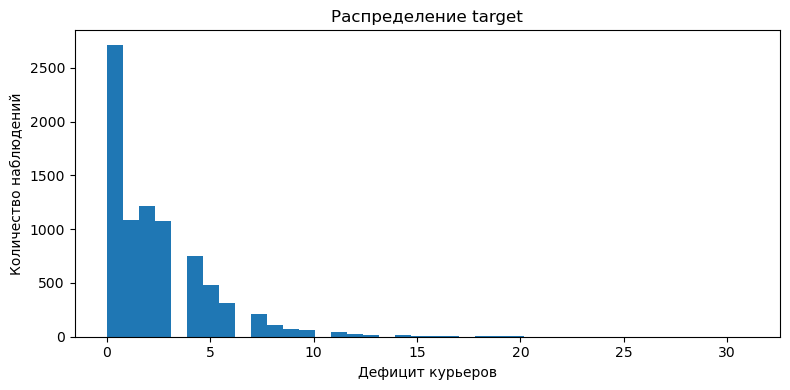

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(df_train['target'], bins=40)
plt.title('Распределение target')
plt.xlabel('Дефицит курьеров')
plt.ylabel('Количество наблюдений')
plt.tight_layout()
plt.show()

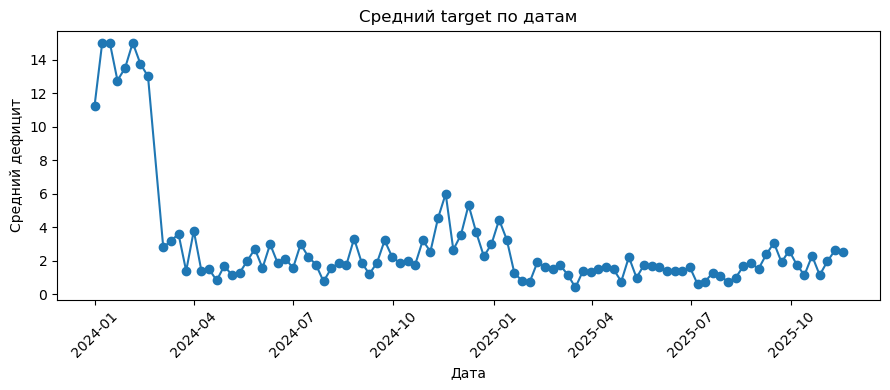

In [11]:
target_by_date = df_train.groupby('calendar_dt')['target'].mean()

plt.figure(figsize=(9, 4))
plt.plot(target_by_date.index, target_by_date.values, marker='o')
plt.title('Средний target по датам')
plt.xlabel('Дата')
plt.ylabel('Средний дефицит')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
train_city = df_train.merge(
    facts[['calendar_dt', 'store_id', 'city_nm']],
    on=['calendar_dt', 'store_id'],
    how='left'
)

city_target = (
    train_city
    .groupby('city_nm')['target']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

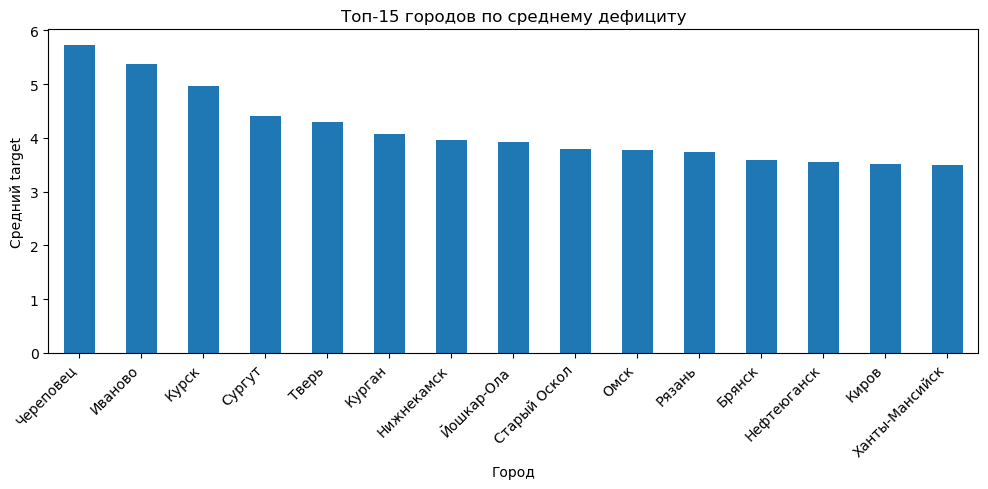

In [13]:
plt.figure(figsize=(10, 5))
city_target.plot(kind='bar')
plt.title('Топ-15 городов по среднему дефициту')
plt.xlabel('Город')
plt.ylabel('Средний target')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
num_cols = df_train.select_dtypes(include='number').columns

In [15]:
shift_week = (
    shifts_prediction
    .groupby('calendar_dt')[['predicted_staff_value', 'predicted_num_orders']]
    .mean()
)

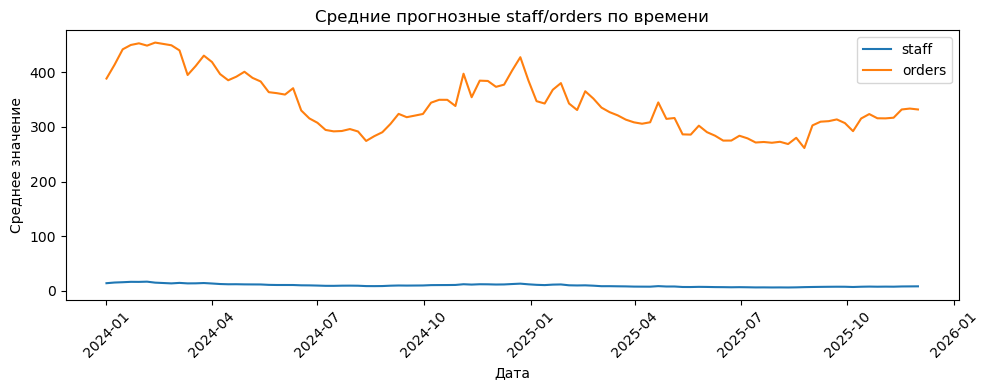

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(shift_week.index, shift_week['predicted_staff_value'], label='staff')
plt.plot(shift_week.index, shift_week['predicted_num_orders'], label='orders')
plt.title('Средние прогнозные staff/orders по времени')
plt.xlabel('Дата')
plt.ylabel('Среднее значение')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Обработка данных

На этом этапе создаются дополнительные признаки из истории смен, фактов по магазинам и статистики по городам.  
Важно не использовать данные из будущего, поэтому rolling-признаки считаются через shift(1)

### Генерация признаков из shifts_prediction

In [17]:
s = shifts_prediction.sort_values(['store_id', 'calendar_dt']).copy()

grp_staff = s.groupby('store_id')['predicted_staff_value']
grp_orders = s.groupby('store_id')['predicted_num_orders']

s['hist_staff_mean_4w'] = grp_staff.transform(lambda x: x.shift(1).rolling(4, min_periods=2).mean())
s['hist_staff_mean_12w'] = grp_staff.transform(lambda x: x.shift(1).rolling(12, min_periods=2).mean())
s['hist_staff_mean_26w'] = grp_staff.transform(lambda x: x.shift(1).rolling(26, min_periods=2).mean())
s['hist_staff_std_12w'] = grp_staff.transform(lambda x: x.shift(1).rolling(12, min_periods=3).std())
s['hist_orders_mean_4w'] = grp_orders.transform(lambda x: x.shift(1).rolling(4, min_periods=2).mean())
s['hist_orders_mean_12w'] = grp_orders.transform(lambda x: x.shift(1).rolling(12, min_periods=2).mean())

In [18]:
def calc_slope(y):
    mask = ~np.isnan(y)
    if mask.sum() < 4:
        return np.nan
    idx = np.arange(len(y))

    try:
        return np.polyfit(idx[mask], y[mask], 1)[0]
    except:
        return np.nan


s['hist_staff_trend_12w'] = grp_staff.transform(lambda x: x.shift(1).rolling(12, min_periods=4).apply(calc_slope, raw=True))
s['hist_orders_trend_12w'] = grp_orders.transform(lambda x: x.shift(1).rolling(12, min_periods=4).apply(calc_slope, raw=True))

In [19]:
s['staff_yoy'] = grp_staff.transform(lambda x: x.shift(52))
s['orders_yoy'] = grp_orders.transform(lambda x: x.shift(52))

s['staff_yoy_ratio'] =  s['predicted_staff_value'] / s['staff_yoy'].replace(0, np.nan)
s['orders_yoy_ratio'] = s['predicted_num_orders'] / s['orders_yoy'].replace(0, np.nan)

s['staff_curr_vs_hist_12w'] = (s['predicted_staff_value'] / s['hist_staff_mean_12w'].replace(0, np.nan))
s['orders_curr_vs_hist_12w'] = ( s['predicted_num_orders'] / s['hist_orders_mean_12w'].replace(0, np.nan))

In [20]:
s['hist_staff_mean_2w'] = grp_staff.transform(lambda x: x.shift(1).rolling(2, min_periods=1).mean())
s['hist_orders_mean_2w'] = grp_orders.transform(lambda x: x.shift(1).rolling(2, min_periods=1).mean())
s['hist_staff_mean_52w'] = grp_staff.transform(lambda x: x.shift(1).rolling(52, min_periods=4).mean())
s['hist_staff_ewm12'] = grp_staff.transform( lambda x: x.shift(1).ewm(span=12, min_periods=3).mean())

In [21]:
std12 = grp_staff.transform(lambda x: x.shift(1).rolling(12, min_periods=3).std())
mean12 = grp_staff.transform(lambda x: x.shift(1).rolling(12, min_periods=3).mean())

s['hist_staff_cv12w'] = std12 / mean12.replace(0, np.nan)
s['hist_staff_max12w'] = grp_staff.transform(lambda x: x.shift(1).rolling(12, min_periods=2).max())
s['hist_staff_min12w'] = grp_staff.transform(lambda x: x.shift(1).rolling(12, min_periods=2).min())

In [22]:
range12 = (s['hist_staff_max12w'] - s['hist_staff_min12w']).replace(0, np.nan)

s['staff_range_position'] = (s['predicted_staff_value'] - s['hist_staff_min12w']) / range12
s['staff_curr_vs_hist_max'] = (s['predicted_staff_value'] / s['hist_staff_max12w'].replace(0, np.nan))
s['staff_yoy_4w_mean'] = grp_staff.transform(lambda x: (x.shift(50) + x.shift(51) + x.shift(52) + x.shift(53)) / 4)
s['staff_short_vs_long'] = (s['hist_staff_mean_2w'] / s['hist_staff_mean_12w'].replace(0, np.nan))
s['staff_vs_yoy4w'] = ( s['predicted_staff_value'] - s['staff_yoy_4w_mean'])

In [23]:
cols = [
    'store_id', 'calendar_dt',
    'hist_staff_mean_4w', 'hist_staff_mean_12w', 'hist_staff_mean_26w',
    'hist_staff_std_12w', 'hist_staff_trend_12w',
    'hist_orders_mean_4w', 'hist_orders_mean_12w', 'hist_orders_trend_12w',
    'staff_yoy', 'orders_yoy', 'staff_yoy_ratio', 'orders_yoy_ratio',
    'staff_curr_vs_hist_12w', 'orders_curr_vs_hist_12w',
    'hist_staff_mean_2w', 'hist_orders_mean_2w', 'hist_staff_mean_52w',
    'hist_staff_ewm12', 'hist_staff_cv12w',
    'hist_staff_max12w', 'hist_staff_min12w',
    'staff_range_position', 'staff_curr_vs_hist_max',
    'staff_yoy_4w_mean', 'staff_short_vs_long', 'staff_vs_yoy4w',
]

shifts_long = s[cols]

print(f'shifts_long: {shifts_long.shape}')
print(f'NaN % hist_staff_mean_12w: {shifts_long.hist_staff_mean_12w.isna().mean():.1%}')
print(f'NaN % hist_staff_cv12w:    {shifts_long.hist_staff_cv12w.isna().mean():.1%}')
print(f'NaN % staff_yoy_4w_mean:   {shifts_long.staff_yoy_4w_mean.isna().mean():.1%}')

shifts_long.head()

shifts_long: (223470, 28)
NaN % hist_staff_mean_12w: 2.5%
NaN % hist_staff_cv12w:    3.7%
NaN % staff_yoy_4w_mean:   60.4%


,store_id,calendar_dt,hist_staff_mean_4w,hist_staff_mean_12w,hist_staff_mean_26w,hist_staff_std_12w,hist_staff_trend_12w,hist_orders_mean_4w,hist_orders_mean_12w,hist_orders_trend_12w,...,hist_staff_mean_52w,hist_staff_ewm12,hist_staff_cv12w,hist_staff_max12w,hist_staff_min12w,staff_range_position,staff_curr_vs_hist_max,staff_yoy_4w_mean,staff_short_vs_long,staff_vs_yoy4w
0,000fade4-e8dc-11ed-b10a-08c0eb31fffb,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000fade4-e8dc-11ed-b10a-08c0eb31fffb,2024-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,000fade4-e8dc-11ed-b10a-08c0eb31fffb,2024-01-15,13.000000,13.000000,13.000000,NaN,NaN,290.000000,290.000000,NaN,...,NaN,NaN,NaN,14.0,12.0,1.500000,1.071429,NaN,1.000000,NaN
3,000fade4-e8dc-11ed-b10a-08c0eb31fffb,2024-01-22,13.666667,13.666667,13.666667,1.527525,NaN,316.666667,316.666667,NaN,...,NaN,13.831409,0.111770,15.0,12.0,0.666667,0.933333,NaN,1.060976,NaN
4,000fade4-e8dc-11ed-b10a-08c0eb31fffb,2024-01-29,13.750000,13.750000,13.750000,1.258306,0.7,325.000000,325.000000,30.0,...,13.75,13.884626,0.091513,15.0,12.0,1.000000,1.000000,NaN,1.054545,NaN


### Признаки на уровне города

In [24]:
train_with_facts = df_train.merge(
    facts[facts.calendar_dt != pd.Timestamp('2025-11-24')][['calendar_dt', 'store_id', 'city_nm', 'fact_staff_churn']],
    on=['calendar_dt', 'store_id'], how='left'
)

city_stats = train_with_facts.groupby('city_nm').agg(
    city_target_mean   = ('target', 'mean'),
    city_target_std    = ('target', 'std'),
    city_target_median = ('target', 'median'),
    city_target_q75    = ('target', lambda x: x.quantile(0.75)),
    city_target_q25    = ('target', lambda x: x.quantile(0.25)),   
    city_churn_mean    = ('fact_staff_churn', 'mean'),
    city_store_count   = ('store_id', 'nunique'),                  
    city_nonzero_rate  = ('target', lambda x: (x > 0).mean()),     
).reset_index()

print('City stats shape:', city_stats.shape)
print(city_stats.sort_values('city_target_mean', ascending=False).head())

City stats shape: (79, 9)
      city_nm  city_target_mean  city_target_std  city_target_median  \
76  Череповец          5.733333         3.850063                 5.0   
14    Иваново          5.370370         5.725437                 4.0   
26      Курск          4.974359         4.251855                 4.0   
63     Сургут          4.404762         3.422020                 4.0   
66      Тверь          4.291667         3.182120                 3.5   

    city_target_q75  city_target_q25  city_churn_mean  city_store_count  \
76             7.75              3.0         3.700000                10   
14             7.00              2.0         3.148148                 9   
26             7.00              2.0         3.179487                13   
63             6.00              2.0         3.214286                14   
66             6.00              2.0         2.937500                16   

    city_nonzero_rate  
76           0.966667  
14           0.888889  
26           0.871

### Основной feature engineering

**Новые признаки:**
- `target_nonzero_rate`: доля лагов с дефицитом > 0 
- `n_lags_available`: сколько лагов доступно (0–3)
- `target_max_available`: максимальный дефицит в доступных лагах
- `deficit_demand_ratio`: lag1 / hist_staff_mean_12w
- `supply_adequacy`: couriers_lag1 / hist_staff_mean_12w
- `orders_per_courier`: fact_orders / fact_staff 
- `lateness_load_product`: lateness × load_factor
- `churn_impact`: churn / hist_staff_mean_12w

In [25]:
def fill_city_median(df, col, city_medians):
    out = df[col].copy()
    mask = out.isna()
    if mask.any():
        city_fill = df['city_nm'].map(city_medians)
        out[mask] = city_fill[mask]
    out = out.fillna(city_medians.median())
    return out

In [26]:
def build_features_v3(df_main, facts_df, shifts_df, shifts_long_df, city_stats_df, df_train_full, is_test=False):
    df = df_main.copy()

    # базовые факты и прогнозы 
    df = df.merge(facts_df, on=['calendar_dt', 'store_id'], how='left')
    df = df.merge(
        shifts_df[['calendar_dt', 'store_id',
                    'predicted_staff_value', 'predicted_num_orders', 'predicted_load_factor']],
        on=['calendar_dt', 'store_id'], how='left')
    df = df.merge(shifts_long_df, on=['calendar_dt', 'store_id'], how='left')
    df = df.merge(city_stats_df, on='city_nm', how='left')

    # лаги таргета
    if not is_test:
        df = df.sort_values(['store_id', 'calendar_dt'])
        for lag in [1, 2, 3, 4, 5]:
            df[f'target_lag{lag}'] = df.groupby('store_id')['target'].shift(lag)
        df['target_roll_mean3'] = df.groupby('store_id')['target'].transform(
            lambda x: x.shift(1).rolling(3, min_periods=1).mean())
        df['target_roll_mean6'] = df.groupby('store_id')['target'].transform(
            lambda x: x.shift(1).rolling(6, min_periods=1).mean())
        df['target_roll_std3']  = df.groupby('store_id')['target'].transform(
            lambda x: x.shift(1).rolling(3, min_periods=1).std())
    else:
        for lag in [1, 2, 3, 4, 5]:
            lag_date = pd.Timestamp('2025-11-24') - pd.Timedelta(weeks=lag)
            lkp = (df_train_full[df_train_full.calendar_dt == lag_date]
                   [['store_id', 'target']].rename(columns={'target': f'target_lag{lag}'}))
            df = df.merge(lkp, on='store_id', how='left')
        df['target_roll_mean3'] = df[['target_lag1','target_lag2','target_lag3']].mean(axis=1)
        df['target_roll_mean6'] = df[['target_lag1','target_lag2','target_lag3',
                                       'target_lag4','target_lag5']].mean(axis=1)
        df['target_roll_std3']  = df[['target_lag1','target_lag2','target_lag3']].std(axis=1)

    city_marketing_med  = df.groupby('city_nm')['marketing_costs_lag_1'].median()
    city_lateness_med   = df.groupby('city_nm')['fact_percent_lateness_lag_1'].median()
    df['marketing_costs_lag_1']       = fill_city_median(df, 'marketing_costs_lag_1', city_marketing_med)
    df['fact_percent_lateness_lag_1'] = fill_city_median(df, 'fact_percent_lateness_lag_1', city_lateness_med)

    df['effective_couriers']     = df['fact_couriers_with_shifts_lag_1'] - df['fact_staff_churn']
    df['expected_deficit_proxy'] = df['predicted_staff_value'] - df['effective_couriers']
    df['actual_surplus_lag1']    = df['num_available_couriers_lag_1'] - df['fact_staff_value_lag_1']
    df['load_ratio']   = df['fact_load_factor_lag_1'] / df['predicted_load_factor'].replace(0, np.nan)
    df['orders_ratio'] = df['fact_num_orders_lag_1']  / df['predicted_num_orders'].replace(0, np.nan)
    df['target_trend'] = df['target_lag1'] - df['target_lag2']
    df['churn_rate']   = df['fact_staff_churn'] / df['fact_couriers_with_shifts_lag_1'].replace(0, np.nan)
    df['is_new_store'] = df['target_lag2'].isna().astype(float)
    df['effective_vs_hist']  = df['effective_couriers']  / df['hist_staff_mean_12w'].replace(0, np.nan)
    df['churn_vs_hist']      = df['fact_staff_churn']    / df['hist_staff_mean_12w'].replace(0, np.nan)
    df['net_supply_stress']  = df['expected_deficit_proxy'] / df['hist_staff_mean_12w'].replace(0, np.nan)
    df['predicted_vs_avail'] = df['predicted_staff_value'] - df['num_available_couriers_lag_1']
    df['staff_demand_accel']  = df['hist_staff_mean_4w'] - df['hist_staff_mean_12w']
    df['orders_demand_accel'] = df['hist_orders_mean_4w'] - df['hist_orders_mean_12w']
    df['staff_plan_anomaly']  = df['predicted_staff_value'] - df['hist_staff_mean_12w']
    df['orders_plan_anomaly'] = df['predicted_num_orders']  - df['hist_orders_mean_12w']
    df['lag1_vs_city_mean']   = df['target_lag1'] - df['city_target_mean']


    # Дефицит-персистентность
    lag_cols = [c for c in ['target_lag1','target_lag2','target_lag3'] if c in df.columns]
    df['target_nonzero_rate']  = (df[lag_cols] > 0).mean(axis=1)
    df['n_lags_available']     = df[lag_cols].notna().sum(axis=1).astype(float)
    df['target_max_available'] = df[lag_cols].max(axis=1)

    # Дефицит относительно спроса
    df['deficit_demand_ratio'] = df['target_lag1'] / df['hist_staff_mean_12w'].replace(0, np.nan)

    # Обеспеченность курьерами относительно исторической нормы
    df['supply_adequacy'] = df['fact_couriers_with_shifts_lag_1'] / df['hist_staff_mean_12w'].replace(0, np.nan)

    # Нагрузка на курьера (заказы/курьер)
    df['orders_per_courier'] = df['fact_num_orders_lag_1'] / df['fact_staff_value_lag_1'].replace(0, np.nan)

    # Взаимодействие: нагрузка × опоздания
    df['lateness_load_product'] = df['fact_percent_lateness_lag_1'] * df['fact_load_factor_lag_1']

    # Воздействие оттока на спрос
    df['churn_impact'] = df['fact_staff_churn'] / df['hist_staff_mean_12w'].replace(0, np.nan)

    # Магазин относительно медианы города
    df['store_vs_city_ratio'] = df['target_lag1'] / df['city_target_mean'].replace(0, np.nan)

    # Отклонение EWM от простого mean (краткосрочный тренд)
    df['ewm_vs_mean12'] = df['hist_staff_ewm12'] - df['hist_staff_mean_12w']

    # Сезонное отклонение от прошлого года
    df['curr_vs_yoy4w_ratio'] = df['predicted_staff_value'] / df['staff_yoy_4w_mean'].replace(0, np.nan)

    return df

In [27]:
df_train = df_train.sort_values(['store_id', 'calendar_dt']).reset_index(drop=True)

In [28]:
df_train_feat = build_features_v3(
    df_train,
    facts[facts.calendar_dt != pd.Timestamp('2025-11-24')],
    shifts_prediction[shifts_prediction.calendar_dt != pd.Timestamp('2025-11-24')],
    shifts_long[shifts_long.calendar_dt != pd.Timestamp('2025-11-24')],
    city_stats, df_train
)

In [29]:
OUTLIER_THRESH = 23
n_before = len(df_train_feat)
df_train_feat = df_train_feat[df_train_feat['target'] <= OUTLIER_THRESH].reset_index(drop=True)
print(n_before - len(df_train_feat))

3


In [30]:
test_with_dt = df_test.copy()
test_with_dt['calendar_dt'] = pd.Timestamp('2025-11-24')

In [31]:
df_test_feat = build_features_v3(
    test_with_dt,
    facts[facts.calendar_dt == pd.Timestamp('2025-11-24')],
    shifts_prediction[shifts_prediction.calendar_dt == pd.Timestamp('2025-11-24')],
    shifts_long[shifts_long.calendar_dt == pd.Timestamp('2025-11-24')],
    city_stats, df_train, is_test=True
)

In [32]:
print(f'Train: {df_train_feat.shape}')
print(f'Test:  {df_test_feat.shape}')

Train: (8217, 87)
Test:  (2438, 86)


In [33]:
FEATURE_COLS = [
    'fact_staff_value_lag_1', 'fact_load_factor_lag_1', 'num_available_couriers_lag_1',
    'fact_num_orders_lag_1', 'fact_percent_lateness_lag_1', 'fact_staff_churn',
    'flag_high_load_lag_1', 'marketing_costs_lag_1', 'fact_couriers_with_shifts_lag_1',
    'city_nm', 'store_lifetime_in_days', 'predicted_staff_value',
    'predicted_num_orders', 'predicted_load_factor', 'target_lag1',
    'target_lag2', 'target_lag3', 'target_roll_mean3',
    'target_roll_std3', 'effective_couriers', 'expected_deficit_proxy',
    'actual_surplus_lag1', 'load_ratio', 'orders_ratio',
    'target_trend', 'churn_rate', 'is_new_store',
    'hist_staff_mean_4w', 'hist_staff_mean_12w', 'hist_staff_mean_26w',
    'hist_staff_std_12w', 'hist_staff_trend_12w', 'hist_orders_mean_4w',
    'hist_orders_mean_12w', 'hist_orders_trend_12w', 'staff_yoy',
    'orders_yoy', 'staff_yoy_ratio', 'orders_yoy_ratio',
    'staff_curr_vs_hist_12w', 'orders_curr_vs_hist_12w',
    'city_target_mean', 'city_target_std', 'city_target_median',
    'city_target_q75', 'city_churn_mean', 'effective_vs_hist',
    'churn_vs_hist', 'net_supply_stress', 'predicted_vs_avail',
    'staff_demand_accel', 'orders_demand_accel', 'staff_plan_anomaly',
    'orders_plan_anomaly', 'lag1_vs_city_mean', 'target_lag4',
    'target_lag5', 'target_roll_mean6', 'hist_staff_mean_2w',
    'hist_orders_mean_2w', 'hist_staff_mean_52w', 'hist_staff_ewm12',
    'hist_staff_cv12w', 'hist_staff_max12w', 'hist_staff_min12w',
    'staff_range_position', 'staff_curr_vs_hist_max',
    'staff_yoy_4w_mean', 'staff_short_vs_long', 'staff_vs_yoy4w',
    'target_nonzero_rate', 'n_lags_available', 'target_max_available',
    'deficit_demand_ratio', 'supply_adequacy', 'orders_per_courier',
    'lateness_load_product', 'churn_impact', 'store_vs_city_ratio',
    'city_target_q25', 'city_store_count', 'city_nonzero_rate',
    'ewm_vs_mean12', 'curr_vs_yoy4w_ratio',
]

In [34]:
CAT_COLS = ['city_nm']

missing_train = [f for f in FEATURE_COLS if f not in df_train_feat.columns]
missing_test  = [f for f in FEATURE_COLS if f not in df_test_feat.columns]
print(f'Отсутствуют в train: {missing_train}')
print(f'Отсутствуют в test:  {missing_test}')
print(f'Всего признаков: {len(FEATURE_COLS)}')

Отсутствуют в train: []
Отсутствуют в test:  []
Всего признаков: 84


In [35]:
from sklearn.preprocessing import LabelEncoder

In [36]:
le = LabelEncoder()
le.fit(pd.concat([df_train_feat['city_nm'], df_test_feat['city_nm']]).fillna('Unknown'))

LabelEncoder()

In [37]:
def to_num(df):
    out = df[FEATURE_COLS].copy()
    out['city_nm'] = le.transform(df['city_nm'].fillna('Unknown'))
    return out

## 3. Time-series validation

- **Fold 1**: train=2025-11-03, val=2025-11-10
- **Fold 2**: train=2025-11-03+10, val=2025-11-17 (основной)

OOF-предсказания обоих фолдов используются для обучения Ridge-стекинга

In [38]:
# Fold 2 
train_mask2 = df_train_feat['calendar_dt'] < pd.Timestamp('2025-11-17')
val_mask2   = df_train_feat['calendar_dt'] == pd.Timestamp('2025-11-17')

X_tr2  = df_train_feat.loc[train_mask2, FEATURE_COLS]
y_tr2  = df_train_feat.loc[train_mask2, 'target']
X_val2 = df_train_feat.loc[val_mask2,   FEATURE_COLS]
y_val2 = df_train_feat.loc[val_mask2,   'target']
w_tr2  = (y_tr2 + 1).values

# Fold 1 
train_mask1 = df_train_feat['calendar_dt'] < pd.Timestamp('2025-11-10')
val_mask1   = df_train_feat['calendar_dt'] == pd.Timestamp('2025-11-10')

X_tr1  = df_train_feat.loc[train_mask1, FEATURE_COLS]
y_tr1  = df_train_feat.loc[train_mask1, 'target']
X_val1 = df_train_feat.loc[val_mask1,   FEATURE_COLS]
y_val1 = df_train_feat.loc[val_mask1,   'target']
w_tr1  = (y_tr1 + 1).values

print(f'Fold1 train: {len(X_tr1)} | val: {len(X_val1)}')
print(f'Fold2 train: {len(X_tr2)} | val: {len(X_val2)}')
print(f'WAPE-aware weight: mean={w_tr2.mean():.2f}, max={w_tr2.max():.0f}')

Fold1 train: 3345 | val: 2434
Fold2 train: 5779 | val: 2438
WAPE-aware weight: mean=3.29, max=21


## 4 Обучение 

In [39]:
from catboost import CatBoostRegressor
import lightgbm as lgb
import xgboost as xgb
import optuna
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge
from scipy.optimize import minimize

In [40]:
def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    denom = np.sum(y_true)
    if denom == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom

### CatBoost

In [44]:
def objective_cat(trial):
    params = dict(
        iterations=2000,
        learning_rate=trial.suggest_float('lr', 0.01, 0.15, log=True),
        depth=trial.suggest_int('depth', 4, 8),
        l2_leaf_reg=trial.suggest_float('l2', 1, 40, log=True),
        min_data_in_leaf=trial.suggest_int('mdl', 1, 50),
        subsample=trial.suggest_float('sub', 0.5, 1.0),
        rsm=trial.suggest_float('rsm', 0.4, 1.0),
        random_strength=trial.suggest_float('rs', 0.1, 5),
        loss_function='MAE',
        cat_features=CAT_COLS,
        random_seed=42,
        verbose=0,
        early_stopping_rounds=60,
    )
    m = CatBoostRegressor(**params)
    m.fit(X_tr2, y_tr2, eval_set=(X_val2, y_val2), sample_weight=w_tr2)
    return wape(y_val2, m.predict(X_val2))


In [45]:
study_cat = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=60, show_progress_bar=True)
print(f'CatBoost лучший WAPE = {study_cat.best_value:.4f}')
print(f'Параметры: {study_cat.best_params}')

[I 2026-05-24 18:47:56,585] A new study created in memory with name: no-name-d0429a50-8431-4553-98f2-9d854ab041ab


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-05-24 18:48:00,007] Trial 0 finished with value: 0.18191779799751603 and parameters: {'lr': 0.02757359293934948, 'depth': 8, 'l2': 14.883264778321262, 'mdl': 30, 'sub': 0.5780093202212182, 'rsm': 0.49359671220172163, 'rs': 0.38460969962417735}. Best is trial 0 with value: 0.18191779799751603.
[I 2026-05-24 18:48:01,016] Trial 1 finished with value: 0.19303714278058032 and parameters: {'lr': 0.10440040750544663, 'depth': 7, 'l2': 13.626199648277185, 'mdl': 2, 'sub': 0.9849549260809971, 'rsm': 0.899465584480253, 'rs': 1.1404616423235534}. Best is trial 0 with value: 0.18191779799751603.
[I 2026-05-24 18:48:04,588] Trial 2 finished with value: 0.18561506059988594 and parameters: {'lr': 0.016362239850894633, 'depth': 4, 'l2': 3.0719512902674277, 'mdl': 27, 'sub': 0.7159725093210578, 'rsm': 0.5747374841188252, 'rs': 3.0980791841396598}. Best is trial 0 with value: 0.18191779799751603.
[I 2026-05-24 18:48:08,882] Trial 3 finished with value: 0.18173394734326098 and parameters: {'lr':

### LightGBM

In [51]:
def objective_lgb(trial):
    params = dict(
        objective='regression_l1', metric='mae', verbose=-1, seed=42,
        learning_rate=trial.suggest_float('lr', 0.01, 0.15, log=True),
        num_leaves=trial.suggest_int('nl', 15, 200),
        min_child_samples=trial.suggest_int('mcs', 5, 80),
        subsample=trial.suggest_float('sub', 0.5, 1.0),
        colsample_bytree=trial.suggest_float('cst', 0.4, 1.0),
        reg_alpha=trial.suggest_float('ra', 0.0, 5.0),
        reg_lambda=trial.suggest_float('rl', 0.1, 30, log=True),
        min_split_gain=trial.suggest_float('msg', 0.0, 2.0),
        max_bin=trial.suggest_int('mb', 63, 511),
    )
    ds = lgb.Dataset(to_num(X_tr2), y_tr2, weight=w_tr2,
                     categorical_feature=[FEATURE_COLS.index('city_nm')])
    dv = lgb.Dataset(to_num(X_val2), y_val2, reference=ds)
    m  = lgb.train(params, ds, 2000, valid_sets=[dv],
                   callbacks=[lgb.early_stopping(60), lgb.log_evaluation(-1)])
    return wape(y_val2, m.predict(to_num(X_val2)))

In [52]:
study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))

[I 2026-05-24 18:53:41,117] A new study created in memory with name: no-name-e8b6ea59-cfc3-4d3c-9d51-c4c66e806ddd


In [53]:
study_lgb.optimize(objective_lgb, n_trials=40, show_progress_bar=True)
print(f'LightGBM лучший WAPE = {study_lgb.best_value:.4f}')
print(f'Параметры: {study_lgb.best_params}')

  0%|          | 0/40 [00:00<?, ?it/s]

Training until validation scores don't improve for 60 rounds
Early stopping, best iteration is:
[296]	valid_0's l1: 0.506005
[I 2026-05-24 18:53:45,814] Trial 0 finished with value: 0.19749759249103116 and parameters: {'lr': 0.02757359293934948, 'nl': 191, 'mcs': 60, 'sub': 0.7993292420985183, 'cst': 0.4936111842654619, 'ra': 0.7799726016810132, 'rl': 0.13927723945289014, 'msg': 1.7323522915498704, 'mb': 332}. Best is trial 0 with value: 0.19749759249103116.
Training until validation scores don't improve for 60 rounds
Early stopping, best iteration is:
[169]	valid_0's l1: 0.499627
[I 2026-05-24 18:53:46,982] Trial 1 finished with value: 0.19571690008420847 and parameters: {'lr': 0.06803900745073706, 'nl': 18, 'mcs': 78, 'sub': 0.9162213204002109, 'cst': 0.5274034664069657, 'ra': 0.9091248360355031, 'rl': 0.28465263577610933, 'msg': 0.6084844859190754, 'mb': 298}. Best is trial 1 with value: 0.19571690008420847.
Training until validation scores don't improve for 60 rounds
Early stopping

### XGBoost

In [54]:
def objective_xgb(trial):
    params = dict(
        objective='reg:absoluteerror', eval_metric='mae',
        seed=42, verbosity=0,
        learning_rate=trial.suggest_float('lr', 0.01, 0.15, log=True),
        max_depth=trial.suggest_int('md', 3, 8),
        reg_lambda=trial.suggest_float('rl', 0.1, 30, log=True),
        reg_alpha=trial.suggest_float('ra', 0.0, 5.0),
        subsample=trial.suggest_float('sub', 0.5, 1.0),
        colsample_bytree=trial.suggest_float('cst', 0.4, 1.0),
        min_child_weight=trial.suggest_int('mcw', 1, 30),
        gamma=trial.suggest_float('gam', 0.0, 5.0),
    )
    dtr = xgb.DMatrix(to_num(X_tr2), label=y_tr2, weight=w_tr2)
    dvl = xgb.DMatrix(to_num(X_val2), label=y_val2)
    m = xgb.train(params, dtr, 2000, [(dvl, 'val')], early_stopping_rounds=60, verbose_eval=False)
    return wape(y_val2, m.predict(dvl))

In [55]:
study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))

[I 2026-05-24 18:57:13,933] A new study created in memory with name: no-name-ef862fc5-4fa2-4ea4-9719-bbd8c9017939


In [58]:
study_xgb.optimize(objective_xgb, n_trials=40, show_progress_bar=True)
print(f'XGBoost  лучший WAPE = {study_xgb.best_value:.4f}')
print(f'Параметры: {study_xgb.best_params}')

  0%|          | 0/40 [00:00<?, ?it/s]

/home/fedor/anaconda3/lib/python3.13/site-packages/xgboost/core.py:747: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[I 2026-05-24 18:59:02,522] Trial 0 finished with value: 0.21553154177450964 and parameters: {'lr': 0.02757359293934948, 'md': 8, 'rl': 6.504856968981274, 'ra': 2.993292420985183, 'sub': 0.5780093202212182, 'cst': 0.49359671220172163, 'mcw': 2, 'gam': 4.330880728874676}. Best is trial 0 with value: 0.21553154177450964.


/home/fedor/anaconda3/lib/python3.13/site-packages/xgboost/core.py:747: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[I 2026-05-24 18:59:03,653] Trial 1 finished with value: 0.20713592282010249 and parameters: {'lr': 0.05092911283433821, 'md': 7, 'rl': 0.11245798259119336, 'ra': 4.8495492608099715, 'sub': 0.9162213204002109, 'cst': 0.5274034664069657, 'mcw': 6, 'gam': 0.9170225492671691}. Best is trial 1 with value: 0.20713592282010249.


...

[I 2026-05-24 18:59:50,577] Trial 37 finished with value: 0.2091848503354173 and parameters: {'lr': 0.03259812796824294, 'md': 8, 'rl': 0.16609380838882953, 'ra': 1.1797900324479988, 'sub': 0.6344418714759296, 'cst': 0.7759795635668952, 'mcw': 4, 'gam': 1.86151826890941}. Best is trial 27 with value: 0.18110505545513714.


/home/fedor/anaconda3/lib/python3.13/site-packages/xgboost/core.py:747: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[I 2026-05-24 18:59:52,182] Trial 38 finished with value: 0.197660748652939 and parameters: {'lr': 0.01918066727719372, 'md': 4, 'rl': 0.7208040397711668, 'ra': 2.5072934271348566, 'sub': 0.6125775563237541, 'cst': 0.40160077676636885, 'mcw': 1, 'gam': 2.3570853924402395}. Best is trial 27 with value: 0.18110505545513714.


/home/fedor/anaconda3/lib/python3.13/site-packages/xgboost/core.py:747: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[I 2026-05-24 18:59:53,933] Trial 39 finished with value: 0.19743730598434886 and parameters: {'lr': 0.024505818947240566, 'md': 7, 'rl': 1.066450609274475, 'ra': 1.35598948932501, 'sub': 0.6895449108494475, 'cst': 0.963659469273145, 'mcw': 19, 'gam': 2.699776991396588}. Best is trial 27 with value: 0.18110505545513714.
XGBoost  лучший WAPE = 0.1811
Параметры: {'lr': 0.06877017624386444, 'md': 3, 'rl': 0.5537720681617769, 'ra': 2.2012199008004867, 'sub': 0.7073943949228975, 'cst': 0.8613218319451745, 'mcw': 17, 'gam': 2.9169105430580413}


### Обучение моделей на validation fold

In [59]:
best_cat = dict(study_cat.best_params)
best_lgb = dict(study_lgb.best_params)
best_xgb = dict(study_xgb.best_params)

In [60]:
cat_cv = CatBoostRegressor(
    iterations=2000,
    learning_rate=best_cat['lr'],
    depth=best_cat['depth'],
    l2_leaf_reg=best_cat['l2'],
    min_data_in_leaf=best_cat['mdl'],
    subsample=best_cat['sub'],
    rsm=best_cat['rsm'],
    random_strength=best_cat['rs'],
    loss_function='MAE',
    cat_features=CAT_COLS,
    random_seed=42,
    verbose=0,
    early_stopping_rounds=60,
)
cat_cv.fit(X_tr2, y_tr2, eval_set=(X_val2, y_val2), sample_weight=w_tr2)
oof_cat = cat_cv.predict(X_val2)
wape_cat = wape(y_val2, oof_cat)
print(f'CatBoost  fold2 WAPE={wape_cat:.4f}  iter={cat_cv.best_iteration_}')

CatBoost  fold2 WAPE=0.1768  iter=648


In [61]:
lgb_params = dict(
    objective='regression_l1',
    metric='mae',
    verbose=-1,
    seed=42,
    learning_rate=best_lgb['lr'],
    num_leaves=best_lgb['nl'],
    min_child_samples=best_lgb['mcs'],
    subsample=best_lgb['sub'],
    colsample_bytree=best_lgb['cst'],
    reg_alpha=best_lgb['ra'],
    reg_lambda=best_lgb['rl'],
    min_split_gain=best_lgb['msg'],
    max_bin=best_lgb['mb'],
)

In [62]:
ds = lgb.Dataset(
    to_num(X_tr2),
    y_tr2,
    weight=w_tr2,
    categorical_feature=[FEATURE_COLS.index('city_nm')]
)
dv = lgb.Dataset(to_num(X_val2), y_val2, reference=ds)
lgb_cv = lgb.train(
    lgb_params,
    ds,
    2000,
    valid_sets=[dv],
    callbacks=[lgb.early_stopping(60), lgb.log_evaluation(200)]
)
oof_lgb = lgb_cv.predict(to_num(X_val2))
wape_lgb = wape(y_val2, oof_lgb)
print(f'LightGBM  fold2 WAPE={wape_lgb:.4f}  iter={lgb_cv.best_iteration}')

Training until validation scores don't improve for 60 rounds
[200]	valid_0's l1: 0.535548
[400]	valid_0's l1: 0.478869
Early stopping, best iteration is:
[426]	valid_0's l1: 0.478315
LightGBM  fold2 WAPE=0.1876  iter=426


In [63]:
xgb_params = dict(
    objective='reg:absoluteerror',
    eval_metric='mae',
    seed=42,
    verbosity=0,
    learning_rate=best_xgb['lr'],
    max_depth=best_xgb['md'],
    reg_lambda=best_xgb['rl'],
    reg_alpha=best_xgb['ra'],
    subsample=best_xgb['sub'],
    colsample_bytree=best_xgb['cst'],
    min_child_weight=best_xgb['mcw'],
    gamma=best_xgb['gam'],
)

In [64]:
dtr = xgb.DMatrix(to_num(X_tr2), label=y_tr2, weight=w_tr2)
dvl = xgb.DMatrix(to_num(X_val2), label=y_val2)
xgb_cv = xgb.train(
    xgb_params,
    dtr,
    2000,
    [(dvl, 'val')],
    early_stopping_rounds=60,
    verbose_eval=False
)
oof_xgb = xgb_cv.predict(dvl)
wape_xgb = wape(y_val2, oof_xgb)
print(f'XGBoost   fold2 WAPE={wape_xgb:.4f}  iter={xgb_cv.best_iteration}')

/home/fedor/anaconda3/lib/python3.13/site-packages/xgboost/core.py:747: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


XGBoost   fold2 WAPE=0.1811  iter=95


### Ансамбль и стекинг

1. Ridge-мета-модель обучается на OOF-предсказаниях 3 базовых моделей
2. Дополнительно Nelder-Mead ищет оптимальные линейные веса
3. Лучшее из двух используется для финального предсказания

In [65]:
OOF_val = np.column_stack([oof_cat, oof_lgb, oof_xgb])
model_names = ['cat', 'lgb', 'xgb']

meta_w = (y_val2.values + 1)
ridge_meta = Ridge(alpha=1.0, positive=True)
ridge_meta.fit(OOF_val, y_val2, sample_weight=meta_w)
pred_meta = np.clip(ridge_meta.predict(OOF_val), 0, None)
wape_meta = wape(y_val2, pred_meta)

print('Ridge meta weights:', dict(zip(model_names, ridge_meta.coef_.round(4))))
print(f'Ridge-стекинг val WAPE={wape_meta:.4f}')
print()

Ridge meta weights: {'cat': np.float64(0.4219), 'lgb': np.float64(0.4768), 'xgb': np.float64(0.2142)}
Ridge-стекинг val WAPE=0.2131



In [66]:
def neg_wape_blend(w):
    w = np.clip(w, 0, None)
    s = w.sum()
    if s == 0:
        return 1.0
    w = w / s
    blend = w[0] * oof_cat + w[1] * oof_lgb + w[2] * oof_xgb
    return wape(y_val2, blend)

In [67]:
res = minimize(
    neg_wape_blend,
    [0.5, 0.25, 0.25],
    method='Nelder-Mead',
    options={'maxiter': 10000, 'xatol': 10-6, 'fatol': 10-6}
)

In [68]:
w_opt = np.clip(res.x, 0, None)
w_opt /= w_opt.sum()
blend_val = np.clip(w_opt[0] * oof_cat + w_opt[1] * oof_lgb + w_opt[2] * oof_xgb, 0, None)

In [69]:
wape_blend = wape(y_val2, blend_val)

In [70]:
print(f'Nelder-Mead веса: cat={w_opt[0]:.3f}, lgb={w_opt[1]:.3f}, xgb={w_opt[2]:.3f}')
print(f'Ансамбль val WAPE = {wape_blend:.4f}')
print()

Nelder-Mead веса: cat=0.512, lgb=0.244, xgb=0.244
Ансамбль val WAPE = 0.1786



In [71]:
if wape_meta < wape_blend:
    USE_STACKING = True
    val_pred_ensemble = pred_meta
    print(f'Используем Ridge стекинг (WAPE={wape_meta:.4f})')
else:
    USE_STACKING = False
    val_pred_ensemble = blend_val
    print(f'Используем Nelder-Mead blend (WAPE={wape_blend:.4f})')

Используем Nelder-Mead blend (WAPE=0.1786)


### Подбор оптимального порога 

Вместо фиксированного`round(x) (порог 0.5) ищем t* ∈ [0, 1] такой, что
floor(x + t*) минимизирует WAPE на валидационной выборке.

In [73]:
best_t = 0.5
best_wape_r = float('inf')
thresholds = np.linspace(0.01, 0.99, 99)

In [74]:
for t in thresholds:
    rounded = np.floor(val_pred_ensemble + t)
    w = wape(y_val2, rounded)
    if w < best_wape_r:
        best_wape_r = w
        best_t = t

In [75]:
print(f'Оптимальный порог: t* = {best_t:.2f}')
print(f'WAPE (raw):         {wape(y_val2, val_pred_ensemble):.4f}')
print(f'WAPE (round 0.5):   {wape(y_val2, np.round(val_pred_ensemble)):.4f}')
print(f'WAPE (opt thresh):  {best_wape_r:.4f}')
print(f'Улучшение vs v2 round: {wape(y_val2, np.round(val_pred_ensemble)) - best_wape_r:.4f}')

Оптимальный порог: t* = 0.42
WAPE (raw):         0.1786
WAPE (round 0.5):   0.1630
WAPE (opt thresh):  0.1586
Улучшение vs v2 round: 0.0043


In [76]:
wape_by_t = []
for t in thresholds:
    wape_by_t.append(wape(y_val2, np.floor(val_pred_ensemble + t)))

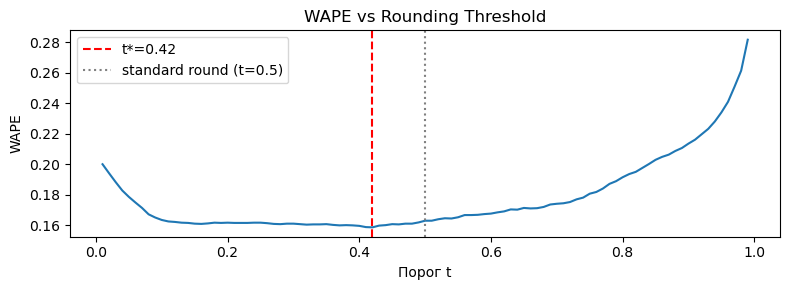

In [77]:
plt.figure(figsize=(8, 3))
plt.plot(thresholds, wape_by_t, linewidth=1.5)
plt.axvline(best_t, color='r', linestyle='--', label=f't*={best_t:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', label='standard round (t=0.5)')
plt.xlabel('Порог t'); plt.ylabel('WAPE'); plt.title('WAPE vs Rounding Threshold')
plt.legend(); plt.tight_layout(); plt.show()

### Финальное обучение моделей

In [78]:
X_all = df_train_feat[FEATURE_COLS]
y_all = df_train_feat['target']
X_test = df_test_feat[FEATURE_COLS]
w_all = (y_all + 1).values

In [79]:
SCALE = len(X_all) / len(X_tr2)
print(f'Масштаб итераций: {SCALE:.3f}  ({len(X_all)} / {len(X_tr2)} строк)')

BEST_CAT_ITER = cat_cv.best_iteration_
BEST_LGB_ITER = lgb_cv.best_iteration
BEST_XGB_ITER = xgb_cv.best_iteration

CAT_ITERS_FINAL = int(BEST_CAT_ITER * SCALE) + 1
LGB_ITERS_FINAL = int(BEST_LGB_ITER * SCALE) + 1
XGB_ITERS_FINAL = int(BEST_XGB_ITER * SCALE) + 1

print(f'CatBoost:  {BEST_CAT_ITER}  ->  {CAT_ITERS_FINAL}')
print(f'LightGBM:  {BEST_LGB_ITER}  ->  {LGB_ITERS_FINAL}')
print(f'XGBoost:   {BEST_XGB_ITER}  ->  {XGB_ITERS_FINAL}')

Масштаб итераций: 1.422  (8217 / 5779 строк)
CatBoost:  648  ->  922
LightGBM:  426  ->  606
XGBoost:   95  ->  136


In [83]:
cat_final = CatBoostRegressor(
    iterations=CAT_ITERS_FINAL,
    learning_rate=best_cat['lr'],
    depth=best_cat['depth'],
    l2_leaf_reg=best_cat['l2'],
    min_data_in_leaf=best_cat['mdl'],
    subsample=best_cat['sub'],
    rsm=best_cat['rsm'],
    random_strength=best_cat['rs'],
    loss_function='MAE',
    cat_features=CAT_COLS,
    random_seed=42,
    verbose=0,
)
cat_final.fit(X_all, y_all, sample_weight=w_all)
tp_cat = cat_final.predict(X_test)
print(f'CatBoost: {CAT_ITERS_FINAL} iter - done')

CatBoost: 922 iter - done


In [84]:
lgb_final = lgb.train(
    lgb_params,
    lgb.Dataset(
        to_num(X_all),
        y_all,
        weight=w_all,
        categorical_feature=[FEATURE_COLS.index('city_nm')]
    ),
    num_boost_round=LGB_ITERS_FINAL,
    callbacks=[lgb.log_evaluation(-1)]
)
tp_lgb = lgb_final.predict(to_num(X_test))
print(f'LightGBM: {LGB_ITERS_FINAL} iter - done')

LightGBM: 606 iter - done


In [85]:
xgb_final = xgb.train(
    xgb_params,
    xgb.DMatrix(to_num(X_all), label=y_all, weight=w_all),
    num_boost_round=XGB_ITERS_FINAL,
    verbose_eval=False
)
tp_xgb = xgb_final.predict(xgb.DMatrix(to_num(X_test)))
print(f'XGBoost:  {XGB_ITERS_FINAL} iter - done')

XGBoost:  136 iter - done


## 5 Предсказание и submission

In [86]:
TEST_MAT = np.column_stack([tp_cat, tp_lgb, tp_xgb])

if USE_STACKING:
    raw_pred = np.clip(ridge_meta.predict(TEST_MAT), 0, None)
    print('Использован Ridge стекинг')
else:
    raw_pred = np.clip(w_opt[0] * tp_cat + w_opt[1] * tp_lgb + w_opt[2] * tp_xgb,0, None)
    print('Использован Nelder-Mead blend')

Использован Nelder-Mead blend


In [87]:
test_pred = np.floor(raw_pred + best_t)
test_pred = np.clip(test_pred, 0, None)

submission = pd.DataFrame({
    'store_id': df_test['store_id'],
    'target': test_pred
}).sort_values('store_id').reset_index(drop=True)

In [88]:
submission.to_csv('answer.csv', index=False)
print(submission['target'].describe())
submission.head(10)

count    2438.000000
mean        2.408121
std         2.497181
min         0.000000
25%         0.000000
50%         2.000000
75%         4.000000
max        16.000000
Name: target, dtype: float64


,store_id,target
0,000fade4-e8dc-11ed-b10a-08c0eb31fffb,2.0
1,0022f1b0-b8f8-11ee-b10b-08c0eb31fffb,0.0
2,00440ac1-6a1d-11eb-85a3-1c34dae33151,1.0
3,00442959-9671-11ec-ae6d-08c0eb320147,7.0
4,00562194-569a-11ec-a0ee-ec0d9a21b021,4.0
5,00872c4d-b7c8-11eb-85ab-1c34dae33151,1.0
6,00c531ee-7d23-11ed-b970-08c0eb32008b,0.0
7,00dad17e-50ee-11ef-b973-08c0eb32008b,2.0
8,00f43499-3c96-11f0-9bb2-be3af2b6059f,0.0
9,012f4970-7b40-11ef-ae7a-08c0eb320147,3.0


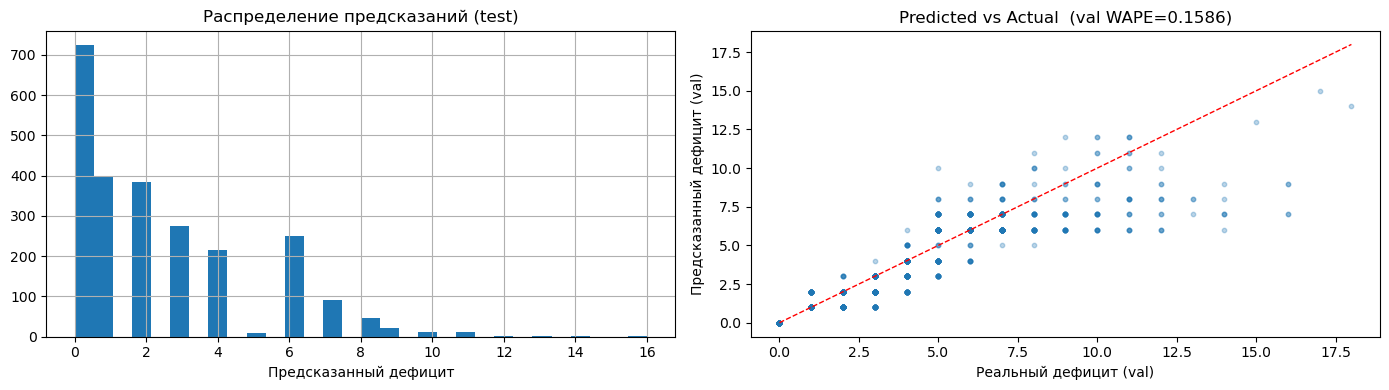

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

submission['target'].hist(bins=30, ax=axes[0])
axes[0].set_title('Распределение предсказаний (test)')
axes[0].set_xlabel('Предсказанный дефицит')

pred_rounded = np.floor(val_pred_ensemble + best_t)
axes[1].scatter(y_val2.values, pred_rounded, alpha=0.3, s=10)
axes[1].plot([0, y_val2.max()], [0, y_val2.max()], 'r--', linewidth=1)
axes[1].set_xlabel('Реальный дефицит (val)')
axes[1].set_ylabel('Предсказанный дефицит (val)')
axes[1].set_title(f'Predicted vs Actual  (val WAPE={best_wape_r:.4f})')

plt.tight_layout()
plt.show()